In [1]:
import torch
import torchvision
from lexplainet.rules import *
from lexplainet.torchvision import ResNet18_canonized

device = "cpu"

def model_loader_resnet18(device):
    model = torchvision.models.resnet18(pretrained=True)
    model = model.to(device)
    model.device = device
    model.eval()
    return model

def getmodel_lrpwrapped_res18_simple(loaded_model):
    composite = {    
        'ReLU':          {"rule": relu_wrapper_fct},
        'MaxPool2d': {"rule": maxpool2d_wrapper_fct},
        'SiLU':          {"rule": relu_wrapper_fct },  
        'BatchNorm2d':   {"rule": relu_wrapper_fct},
        'Conv2d':       {"rule": conv2d_gammalifted_wrapper_fct, "ignore_bias": True, "gamma": 1000, "eps": 1e-3, "beta": 2, "max_beta": 2}, #conv2d_betaadaptive_wrapper_fct,
        'Linear':        {"rule": linear_eps_wrapper_fct, "eps": 1e-3},  
        'AdaptiveAvgPool2d': {"rule": adaptiveavgpool2d_wrapper_fct, "eps": 1e-3},
        'ElementwiseSum': {"rule": eltwisesum_eps_wrapper_fct, "eps": 1e-3},
        }

    model = ResNet18_canonized(pretrained=False)
    model.copyfromresnet(loaded_model, composite=composite)

    model.eval()
    model.to(device)
    model.device = device
    
    return model

model = model_loader_resnet18(device)
modified_model = getmodel_lrpwrapped_res18_simple(model)
modified_model

at src_module_name 
at src_module_name conv1
at src_module_name bn1
Wrap Conv2d
Wrap BatchNorm2d
at src_module_name relu
at src_module_name maxpool
at src_module_name layer1
at src_module_name layer1.0
at src_module_name layer1.0.conv1
at src_module_name layer1.0.bn1
Wrap Conv2d
Wrap BatchNorm2d
at src_module_name layer1.0.relu
at src_module_name layer1.0.conv2
at src_module_name layer1.0.bn2
Wrap Conv2d
Wrap BatchNorm2d
at src_module_name layer1.1
at src_module_name layer1.1.conv1
at src_module_name layer1.1.bn1
Wrap Conv2d
Wrap BatchNorm2d
at src_module_name layer1.1.relu
at src_module_name layer1.1.conv2
at src_module_name layer1.1.bn2
Wrap Conv2d
Wrap BatchNorm2d
at src_module_name layer2
at src_module_name layer2.0
at src_module_name layer2.0.conv1
at src_module_name layer2.0.bn1
Wrap Conv2d
Wrap BatchNorm2d
at src_module_name layer2.0.relu
at src_module_name layer2.0.conv2
at src_module_name layer2.0.bn2
Wrap Conv2d
Wrap BatchNorm2d
at src_module_name layer2.0.downsample
at src_m

/home/erfan/miniconda3/envs/lrp_exercise/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/erfan/miniconda3/envs/lrp_exercise/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet_canonized(
  (conv1): LRPRuleWrapper(
    (module): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
  )
  (bn1): LRPRuleWrapper(
    (module): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (relu): LRPRuleWrapper(
    (module): ReLU(inplace=True)
  )
  (maxpool): LRPRuleWrapper(
    (module): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): BasicBlockFused(
      (conv1): LRPRuleWrapper(
        (module): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (bn1): LRPRuleWrapper(
        (module): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): LRPRuleWrapper(
        (module): ReLU(inplace=True)
      )
      (conv2): LRPRuleWrapper(
        (module): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (bn2): LRPRuleWrapper(
        (module): BatchNorm2d

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

from imagenet import IMAGENET_CLASS_NAMES
from imagenet.utils import inference_transform
from lexplainet.heatmap import show_image, load_image, plot_heatmap

Image Tensor Shape: torch.Size([1, 3, 224, 224])


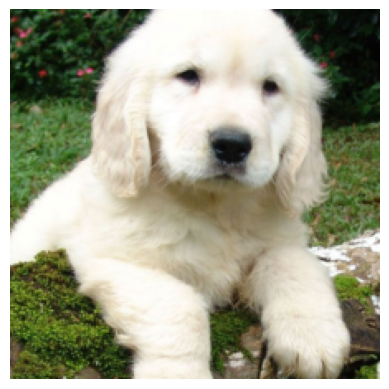

<Figure size 640x480 with 0 Axes>

In [3]:
image_tensor = load_image('./image.png', transform=inference_transform, device=device)
show_image(image_tensor, transform=inference_transform)

In [4]:
from model_utils.inference import inference, forward_pass
from model_utils.autograd import explain_sample

In [5]:
inference(modified_model, image_tensor, class_names=IMAGENET_CLASS_NAMES)

Predicted Class: golden retriever, (Index: 207)


tensor([[-4.7070e-01, -1.8954e+00, -5.0336e-01, -4.1973e+00, -1.6851e+00,
          6.0782e-01, -2.3677e+00, -1.4361e+00, -2.6382e-01, -4.0351e+00,
         -4.6605e+00, -4.5939e+00, -4.0707e+00, -5.1881e+00, -2.6611e+00,
         -5.9938e+00, -4.6652e+00, -3.2820e+00, -4.9043e+00, -4.4323e+00,
         -3.1447e+00, -3.0620e+00, -1.7289e+00, -1.2158e+00,  3.5466e-01,
          1.2089e+00, -1.1222e+00, -1.4081e+00, -8.0454e-01, -9.2138e-01,
         -2.2362e+00, -4.6226e-01, -6.0077e-01, -8.9885e-01,  1.0425e+00,
          9.5297e-01,  4.2205e-01, -1.1491e+00, -2.6020e+00,  3.1155e-01,
         -1.0816e+00, -8.7494e-01, -1.5278e+00, -1.8999e+00, -1.2158e+00,
         -1.2312e+00, -8.9146e-02,  1.1461e+00,  2.4449e-01, -2.2920e+00,
          7.2512e-01,  1.7872e+00, -1.8994e+00, -2.6150e+00, -2.9222e+00,
         -1.9064e+00, -1.6394e+00, -4.7385e+00, -4.1370e+00, -1.9720e+00,
         -1.0208e+00, -2.1911e+00, -2.6790e+00, -3.3631e+00, -2.1723e+00,
         -2.0955e+00, -3.6372e+00, -1.

In [6]:
normalized_relevance, _ = explain_sample(modified_model, image_tensor)

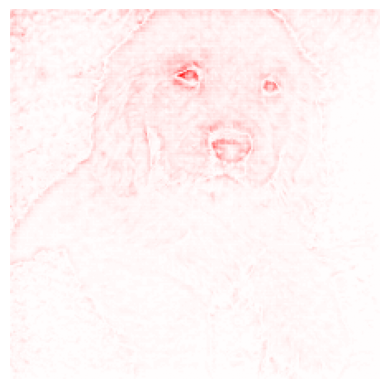

In [7]:
plot_heatmap(normalized_relevance)